In [29]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv("../dataset/medical_insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [31]:
df.shape

(2772, 7)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   str    
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   str    
 5   region    2772 non-null   str    
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 195.5 KB


In [33]:
df.describe()


,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [34]:
df.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [35]:
df.duplicated().sum()


np.int64(1435)

In [36]:
df = df.drop_duplicates()
df.shape

(1337, 7)

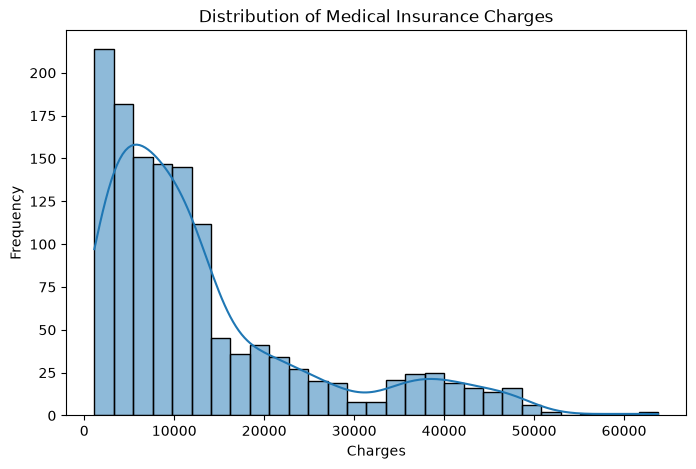

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["charges"],
    kde=True
)

plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.show()

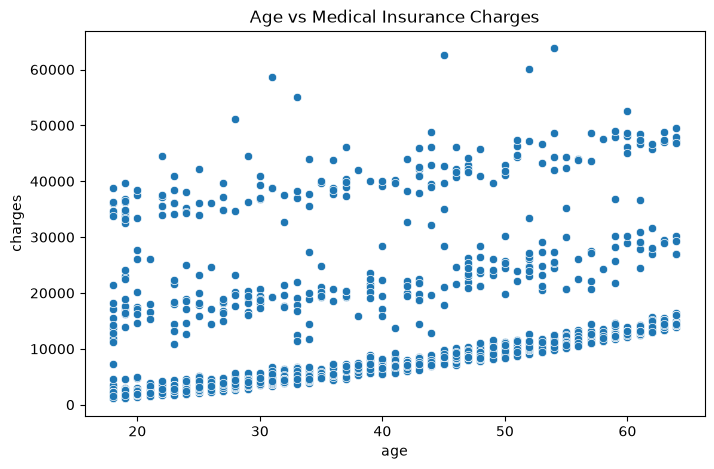

In [38]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="age",
    y="charges"
)

plt.title("Age vs Medical Insurance Charges")

plt.show()

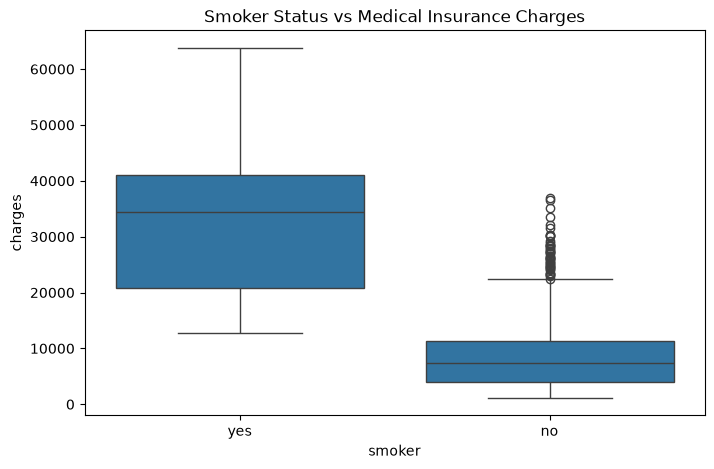

In [39]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="smoker",
    y="charges"
)

plt.title("Smoker Status vs Medical Insurance Charges")

plt.show()

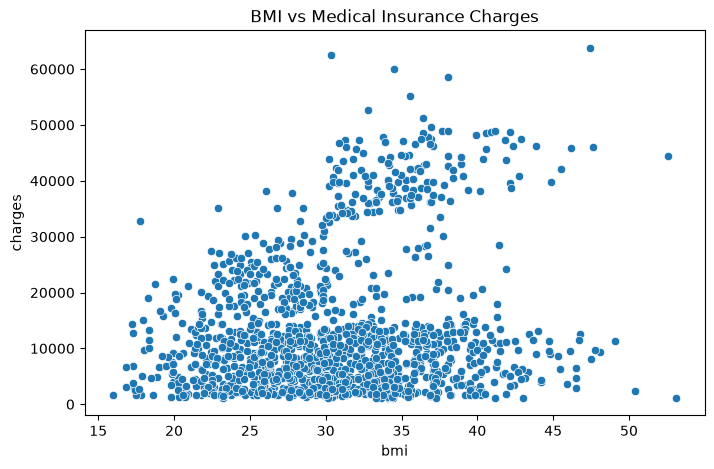

In [40]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges"
)

plt.title("BMI vs Medical Insurance Charges")

plt.show()

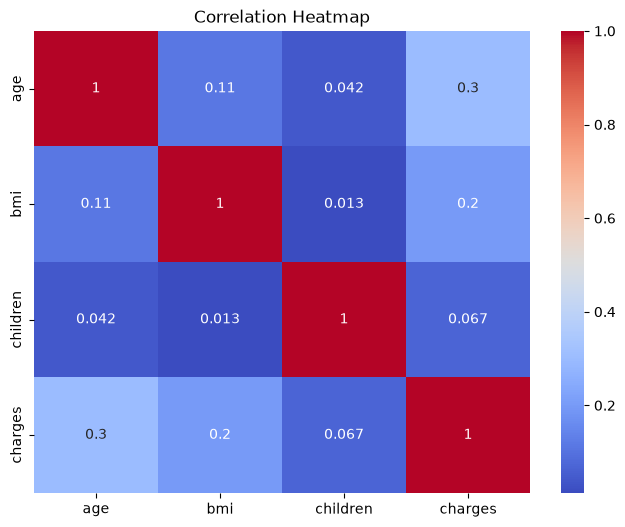

In [41]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

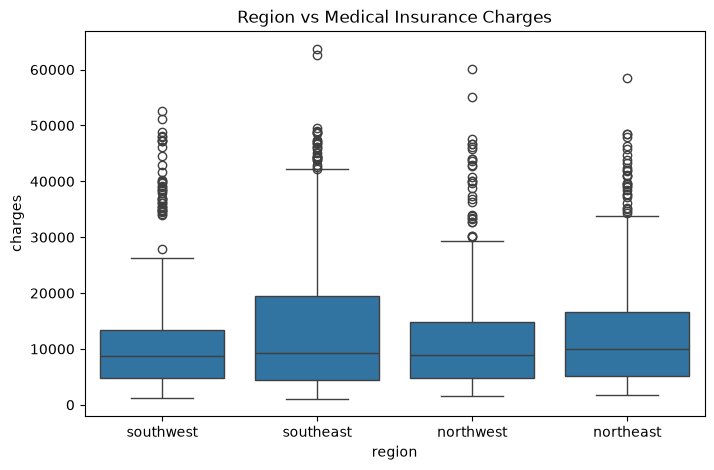

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="region",
    y="charges"
)

plt.title("Region vs Medical Insurance Charges")

plt.show()

In [43]:
df.dtypes


age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [44]:
# --- NEW: feature engineering, added here ---
smoker_flag = (df["smoker"] == "yes").astype(int)
df["smoker_bmi"] = smoker_flag * df["bmi"]
df["bmi_over_30"] = (df["bmi"] > 30).astype(int)
df["smoker_obese"] = smoker_flag * df["bmi_over_30"]
df["age_squared"] = df["age"] ** 2
df["age_smoker"] = df["age"] * smoker_flag

In [45]:
X = df.drop("charges", axis=1)

# no charges

In [46]:
y = df["charges"]

In [47]:
X.head

<bound method NDFrame.head of       age     sex     bmi  children smoker     region  smoker_bmi  \
0      19  female  27.900         0    yes  southwest       27.90   
1      18    male  33.770         1     no  southeast        0.00   
2      28    male  33.000         3     no  southeast        0.00   
3      33    male  22.705         0     no  northwest        0.00   
4      32    male  28.880         0     no  northwest        0.00   
...   ...     ...     ...       ...    ...        ...         ...   
1333   50    male  30.970         3     no  northwest        0.00   
1334   18  female  31.920         0     no  northeast        0.00   
1335   18  female  36.850         0     no  southeast        0.00   
1336   21  female  25.800         0     no  southwest        0.00   
1337   61  female  29.070         0    yes  northwest       29.07   

      bmi_over_30  smoker_obese  age_squared  age_smoker  
0               0             0          361          19  
1               1      

In [48]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [49]:
from sklearn.preprocessing import OneHotEncoder  # non numeric into numeric
from sklearn.compose import ColumnTransformer

In [50]:
categorical_features = [
    "sex",
    "smoker",
    "region"
]


preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [51]:
X_encoded = preprocessor.fit_transform(X)

In [52]:
X_encoded

array([[0.000e+00, 1.000e+00, 0.000e+00, ..., 0.000e+00, 3.610e+02,
        1.900e+01],
       [1.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 3.240e+02,
        0.000e+00],
       [1.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 7.840e+02,
        0.000e+00],
       ...,
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 3.240e+02,
        0.000e+00],
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 4.410e+02,
        0.000e+00],
       [0.000e+00, 1.000e+00, 1.000e+00, ..., 0.000e+00, 3.721e+03,
        6.100e+01]], shape=(1337, 13))

In [53]:
X_encoded = pd.DataFrame(
    X_encoded,
    columns=preprocessor.get_feature_names_out()
)

X_encoded.head()

,cat__sex_male,cat__smoker_yes,cat__region_northwest,cat__region_southeast,cat__region_southwest,remainder__age,remainder__bmi,remainder__children,remainder__smoker_bmi,remainder__bmi_over_30,remainder__smoker_obese,remainder__age_squared,remainder__age_smoker
0,0.0,1.0,0.0,0.0,1.0,19.0,27.900,0.0,27.9,0.0,0.0,361.0,19.0
1,1.0,0.0,0.0,1.0,0.0,18.0,33.770,1.0,0.0,1.0,0.0,324.0,0.0
2,1.0,0.0,0.0,1.0,0.0,28.0,33.000,3.0,0.0,1.0,0.0,784.0,0.0
3,1.0,0.0,1.0,0.0,0.0,33.0,22.705,0.0,0.0,0.0,0.0,1089.0,0.0
4,1.0,0.0,1.0,0.0,0.0,32.0,28.880,0.0,0.0,0.0,0.0,1024.0,0.0


In [54]:
df_encoded = pd.concat(
    [X_encoded, y.reset_index(drop=True)],
    axis=1
)

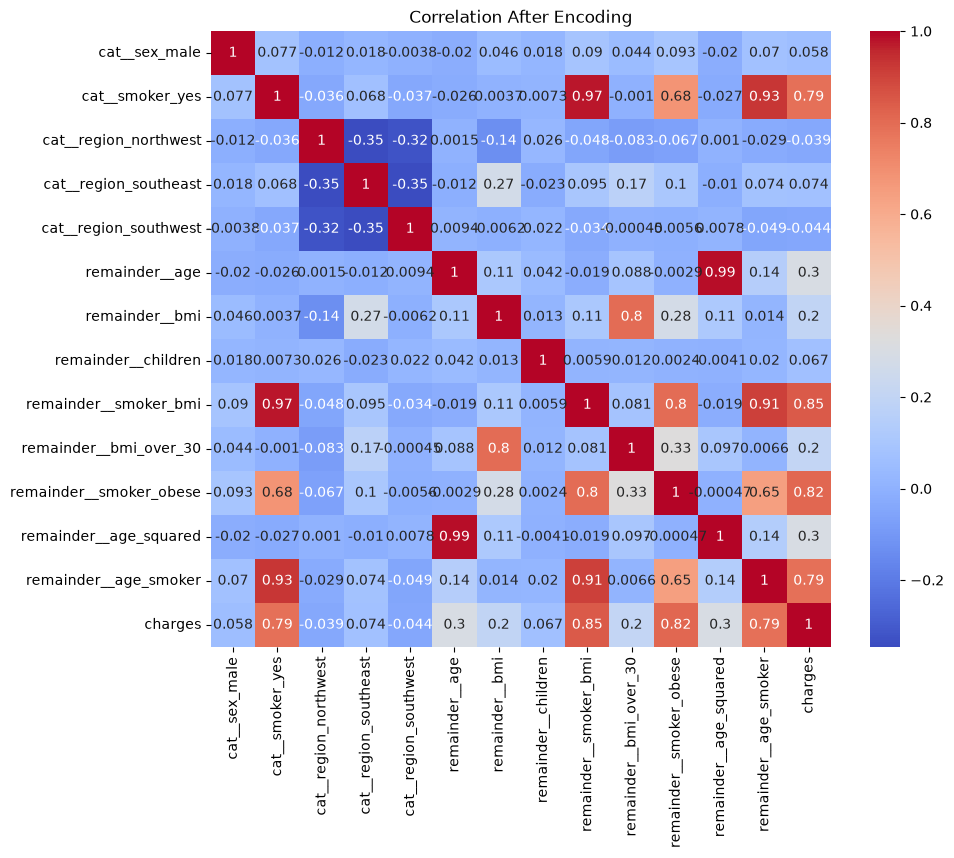

In [55]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation After Encoding")

plt.show()

In [56]:
df_encoded.to_csv("../dataset/medical_insurance_encoded.csv", index=False)

In [57]:
# Q1 = df['charges'].quantile(0.25)
# Q3 = df['charges'].quantile(0.75)

# IQR = Q3 - Q1

# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# outliers = df[
#     (df['charges'] < lower) |
#     (df['charges'] > upper)
# ]

# print(outliers)